# DH Refined Diagnostics — 20260714_v1995 (post-2000, re-fit cells run)

Final-selection notebook for the post-2000 **refined** evaluate run, repointed at
`02-evaluate/20260714_v1995_refined/` — the structure-C cells run (s1 free, s2 free &
independent, `s2 ⊇ bulk ⊇ tail`). Fork of
`20260515/dh_refined_diagnostics_post2000.ipynb`.

Picks up where `dh_intermediate_diagnostics.ipynb` left off. The S1/S2/Bulk/Tail
family/exposure decisions are baked into the refined grid by
`build_refined_specs_post2000.py`; this notebook starts at the assembled-DH layer
and works entirely off `dh_results.parquet` — it does **not** read
`model_predictions/` (the run used `--skip-model-predictions`).

**Convergence gate removed:** the re-fit-in-evaluate pipeline has no separate fit
stage and writes no per-component `.json` sidecars, so the IS/OOS convergence gate
from the 20260517 version is not applicable and has been dropped.

Flow:
1. Load the refined `dh_results.parquet` and aggregate to one row per config (OOS).
2. Asymmetric calibration gate (`full_pred_obs_ratio_oos ∈ [0.1, 1.5]`) + non-finite OOS cull.
3. Per-rule winner trajectories by threshold.
4. Pick metrics → Kendall τ → Borda / TOPSIS → winners-by-covariate-chain.


In [15]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.select.model_query import ModelQuery
from idd_tc_mortality.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    CALIBRATION_METRICS,
    prepare_rankings_df,
    borda_rank,
    pareto_frontier,
    topsis_rank,
    pairwise_dominance_summary,
    cluster_configurations,
    winner_profile,
    kendall_tau_heatmap,
    prune_redundant_metrics
)
from idd_tc_mortality.viz.stage_plots import StagePlotter

# Reuse the qmd's helper module for shared heatmap / winner-panel plots.
sys.path.insert(0, str(Path('../..').resolve() / 'reports'))
import _helpers as H

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Paths

Edit the dates to point at the refined run you want to inspect.

In [16]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260714_v1995_refined'   # structure-C refined cells run
DATA_DATE = '20260714_v1995'           # post-2000 input.parquet (years >= 2000)

RESULTS_PATH = ROOT / '02-evaluate' / EVAL_DATE / 'dh_results.parquet'
EVAL_DIR     = ROOT / '02-evaluate' / EVAL_DATE
DATA_PATH    = ROOT / '00-data'     / DATA_DATE / 'input.parquet'
SPECS_PATH   = ROOT / '01-refined'  / DATA_DATE / 'refined_is_specs.json'  # 336 IS specs (reference only)

for p in (RESULTS_PATH, EVAL_DIR, DATA_PATH):
    assert p.exists(), f'Missing: {p}'
print('All paths resolve.')


All paths resolve.


## Load

In [17]:
dh_results = pd.read_parquet(RESULTS_PATH)
data       = pd.read_parquet(DATA_PATH)

print(f'dh_results : {dh_results.shape[0]:,} rows × {dh_results.shape[1]} cols')
print(f'training   : {data.shape[0]:,} rows × {data.shape[1]} cols')
print(f'fold_tags  : {dh_results["fold_tag"].value_counts().to_dict()}')
print(f'configs    : {dh_results.groupby(CONFIG_COLS, dropna=False).ngroups:,} unique')
print(f'thresholds : {sorted(dh_results["threshold_quantile"].unique())}')

dh_results : 1,376,256 rows × 252 cols
training   : 2,278 rows × 13 cols
fold_tags  : {'insample': 229376, 'oos_seed0': 229376, 'oos_seed1': 229376, 'oos_seed2': 229376, 'oos_seed3': 229376, 'oos_seed4': 229376}
configs    : 229,376 unique
thresholds : [np.float64(0.7), np.float64(0.75), np.float64(0.7999999999999999), np.float64(0.85)]


## Build the rankings dataframe

`prepare_rankings_df(..., subset='oos')` gives one row per config with OOS
metrics averaged across seeds. This is the canonical input to all ranking
methods below.

Then we cull: drop configs with any non-finite OOS metric (failed folds)
and configs outside the calibration gate. Tighten or loosen the cull as
needed.

In [18]:
df_oos = prepare_rankings_df(dh_results, subset='oos')
print(f'{len(df_oos):,} configurations before any cull')


229,376 configurations before any cull


In [19]:
print(f'Before cull: {len(df_oos):,} configs')

# Drop configs with any non-finite OOS metric (failed folds).
oos_numeric = [c for c in df_oos.columns
               if c.endswith('_oos') and pd.api.types.is_numeric_dtype(df_oos[c])]
finite_mask = np.isfinite(df_oos[oos_numeric].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
df_oos = df_oos[finite_mask].copy()
print(f'After non-finite cull: {len(df_oos):,} configs ({n_failed:,} dropped as failures)')

# Asymmetric calibration gate — under-prediction (mega-event honesty)
# allowed; over-prediction (compensating bulk overpred) capped tighter.
# See preliminary_decisions_post2000.qmd §Scope.
RATIO_BOUNDS = (0.05, 1.1)
df_oos = df_oos[df_oos['full_pred_obs_ratio_oos'].between(*RATIO_BOUNDS)].copy()
print(f'After calibration gate [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]: '
      f'{len(df_oos):,} configs')

print('\nPost-cull count per threshold:')
print(df_oos['threshold_quantile'].value_counts().sort_index().to_string())

Before cull: 229,376 configs
After non-finite cull: 229,376 configs (0 dropped as failures)
After calibration gate [0.05, 1.1]: 223,845 configs

Post-cull count per threshold:
threshold_quantile
0.70    57344
0.75    57312
0.80    56704
0.85    52485


### Convergence gate — N/A for the re-fit pipeline

The 20260517 version scanned per-component `{component_id}.json` sidecars in the
fit directory for an IRLS/optimiser `converged` flag. The re-fit-in-evaluate
pipeline has **no fit stage and writes no sidecars** — each component is re-fit
in-memory by the evaluate worker, and convergence is not persisted to
`dh_results.parquet`. So this gate is dropped; `df_oos` after the calibration gate
above is the final candidate pool.


## Per-rule winner trajectories

Same diagnostic as the preliminary qmd's Threshold section, on the refined
survivor pool. For each threshold, six configs are identified — the one
that wins at coverage level 1, 5, 10, 15, 20 (argmax of
`full_coverage_rate_L_oos`), and the one that wins on the mean across all
20 levels — and their full 1..20 trajectories are plotted. Each level-winner
gets a dot at the level where it was picked.

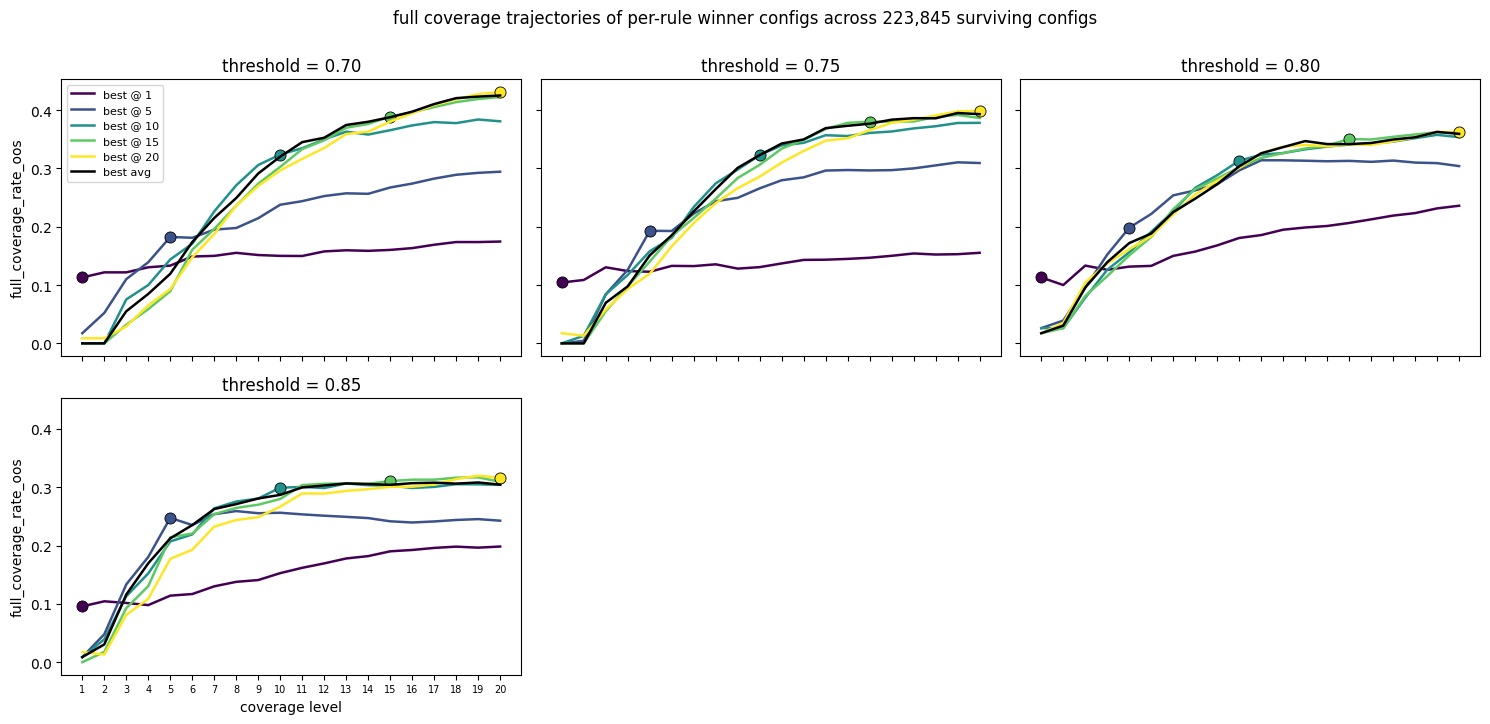


Winner configs per (threshold, rule):
 threshold      rule s1_family s1_exposure_mode                                                                s1_cov s2_family s2_exposure_mode                                                                 s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                                tail_cov
      0.70  best @ 1     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": false}     logit             free   {"basin": false, "is_island": true, "sdi": true, "wind_speed": true} scaled_logit               free   {"basin": false, "is_island": true, "sdi": true, "wind_speed": true}      weibull               free    {"basin": false, "is_island": true, "sdi": true, "wind_speed": true}
      0.70  best @ 5     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": fals

In [20]:
winner_records = H.threshold_winner_panels(df_oos)
plt.show()

print('\nWinner configs per (threshold, rule):')
print(winner_records.to_string(index=False))

## Pick your own metrics

The 13-metric `DEFAULT_METRICS` is just a starting point. Edit the dict
below — comment / uncomment lines — to define the set used downstream.
Both the Kendall heatmap and the ranking step use whatever you set as
`metrics_present` and `calib_present` here.

Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better
- `'calib'`  → closer to 1.0 is better (handled separately by the ranking API)

In [21]:
metrics_to_use = {
    # ---- S1 (binary: P(deaths >= 1)) ----
    's1_auroc_oos':                  'higher',
    # 's1_brier_oos':                'lower',
    # 's1_fpr_oos':                  'lower',
    # 's1_fnr_oos':                  'lower',

    # ---- S2 (binary: P(rate >= thresh | deaths >= 1)) ----
    's2_auroc_oos':                  'higher',
    # 's2_brier_oos':                'lower',

    # ---- Bulk (regression on rate < thresh) ----
    'bulk_mae_rate_oos':             'lower',
    # 'bulk_rmse_rate_oos':          'lower',
    # 'bulk_cor_rate_oos':           'higher',

    # ---- Tail (regression on rate >= thresh) ----
    'tail_mae_rate_oos':             'lower',
    # 'tail_rmse_rate_oos':          'lower',
    # 'tail_cor_rate_oos':           'higher',

    # ---- Full (unconditional E[rate], applies to every row) ----
    'full_mae_rate_oos':             'lower',
    # 'full_rmse_rate_oos':            'lower',
    # 'full_cor_rate_oos':             'higher',
    # 'full_zero_acc_oos':             'higher',
    'full_pred_obs_ratio_oos':       'calib',
    'full_coverage_rate_10_oos':     'higher',
    'full_coverage_count_10_oos':     'higher',

    # ---- Forward (stage-conditional aggregate) ----
    'fwd_mae_rate_oos':              'lower',
    #'fwd_pred_obs_ratio_oos':        'calib',
    # 'fwd_coverage_rate_10_oos':      'higher',
    # 'fwd_coverage_count_10_oos':      'higher',
}

calib_present   = [k for k, v in metrics_to_use.items()
                   if v == 'calib' and k in df_oos.columns]
# metrics_present = {k: v for k, v in metrics_to_use.items()
#                    if v != 'calib' and k in df_oos.columns}
metrics_present = {k: v for k, v in metrics_to_use.items()
                   if k in df_oos.columns}

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:35s}  {d}')
print(f'\nActive calibration metrics ({len(calib_present)}):')
for c in calib_present:
    print(f'  {c}  (closer to 1.0)')

missing = [k for k in metrics_to_use if k not in df_oos.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in df_oos (skipped): {missing}')

Active rank metrics (9):
  s1_auroc_oos                         higher
  s2_auroc_oos                         higher
  bulk_mae_rate_oos                    lower
  tail_mae_rate_oos                    lower
  full_mae_rate_oos                    lower
  full_pred_obs_ratio_oos              calib
  full_coverage_rate_10_oos            higher
  full_coverage_count_10_oos           higher
  fwd_mae_rate_oos                     lower

Active calibration metrics (1):
  full_pred_obs_ratio_oos  (closer to 1.0)


## Kendall τ — metric correlation

Rank correlation between metrics on the culled candidate pool. Tightly
correlated metrics (high τ) are redundant for ranking purposes; an
uncorrelated metric adds independent information.

Computing rank correlations on 223,845 configs × 9 metrics


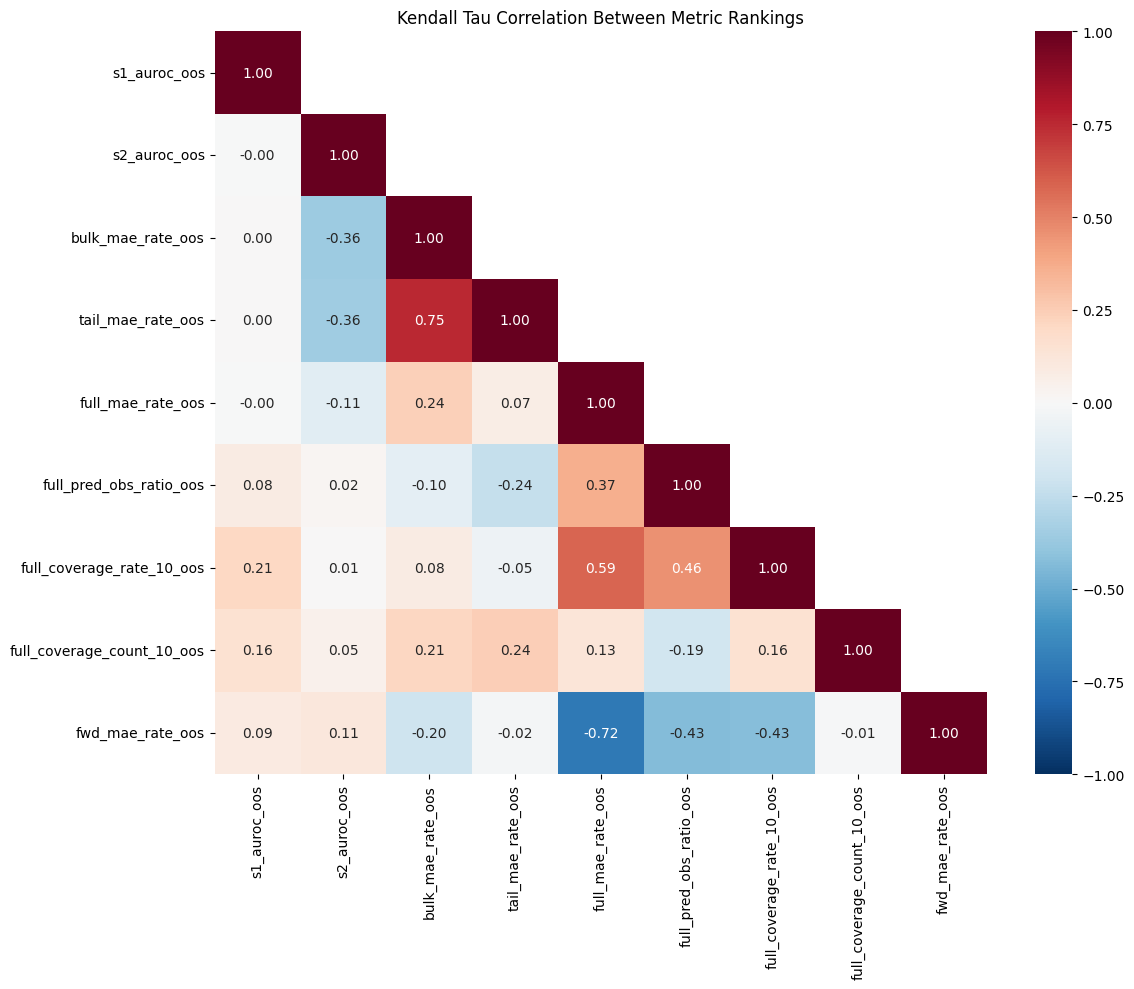


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.022
Pairs with negative correlation: 15
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).
step 1: |τ|=0.751  bulk_mae_rate_oos (0.171) vs tail_mae_rate_oos (0.141)  → drop bulk_mae_rate_oos
step 2: |τ|=0.718  full_mae_rate_oos (0.213) vs fwd_mae_rate_oos (0.183)  → drop full_mae_rate_oos


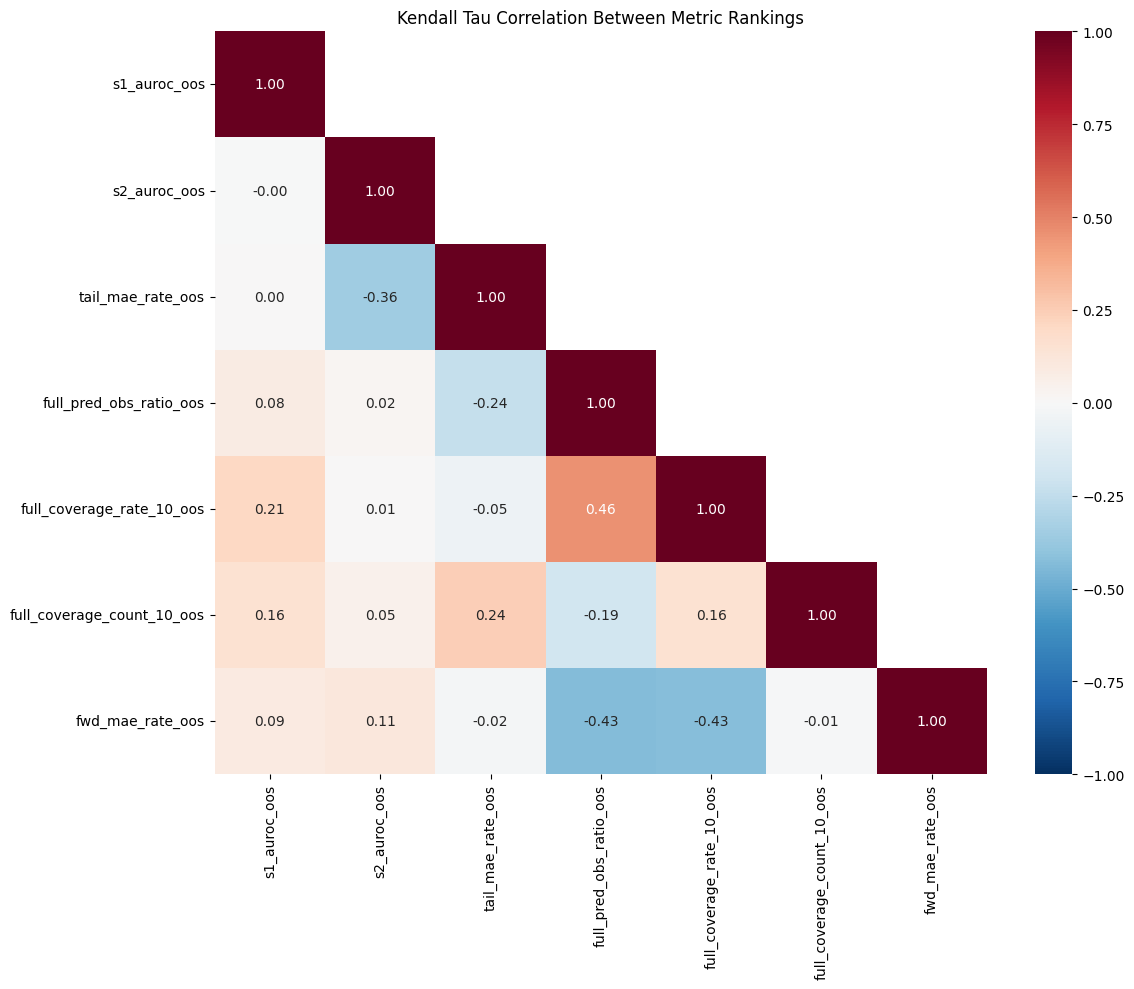


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.007
Pairs with negative correlation: 9
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [22]:
print(f'Computing rank correlations on {len(df_oos):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos, metrics_present, calib_present)
metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(df_oos, metrics_present, calib_present)
plt.show()

## Winners by method

Borda → TOPSIS → Pareto frontier (first row) → pairwise dominance. Each
method picks one top config; the table compares them on a shared metric set.

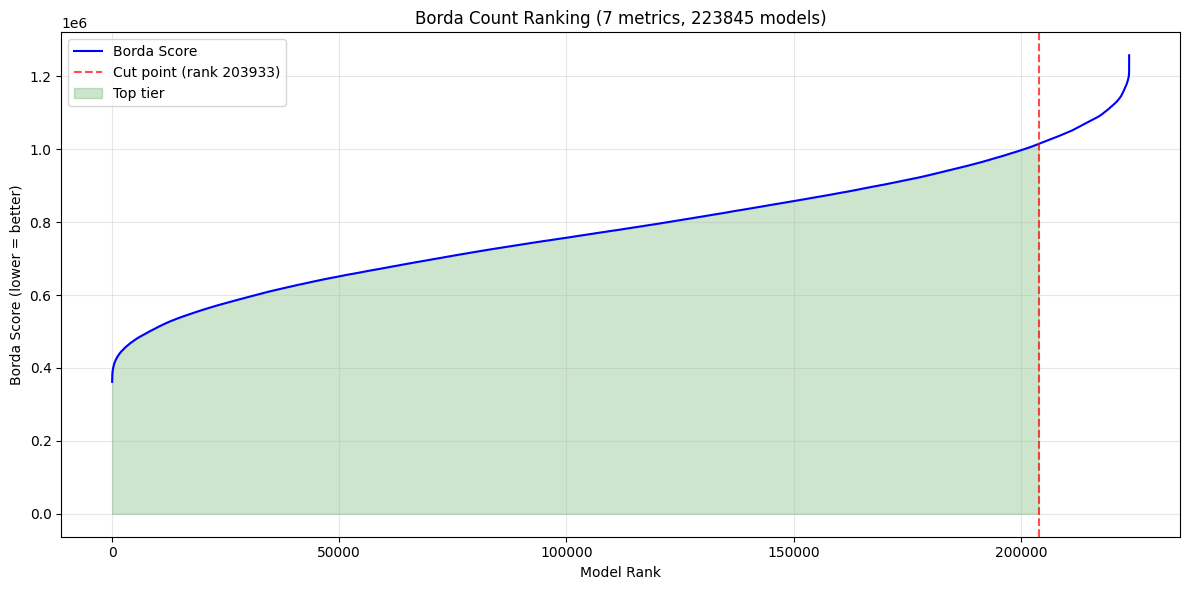


=== Borda Count Summary ===
Total models: 223845
Metrics used: 7
Suggested cutpoint: rank 203933 (top 203933 models)
Top tier Borda range: 361886.0 - 1014562.5
Bottom tier starts at: 1014565.5


In [23]:
borda_df, _    = borda_rank(df_oos, metrics_present, calib_present)

In [24]:
top_borda_df = borda_df[borda_df['borda_rank'] <= 281].copy()
# table of quantile, tail_family, and covariate configuration
summary_quality = (top_borda_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('borda_rank', 'count'),
        median_rank=('borda_rank', 'median'),
        min_rank=('borda_rank', 'min'),
        max_rank=('borda_rank', 'max'),
        median_score=('borda_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

    threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
11                0.75  log_logistic             weight        free+weight         60        119.5       4.0     274.0     392288.00
8                 0.75           gpd             weight        free+weight         69        121.0       1.0     281.0     392418.00
7                 0.75           gpd             weight               free         42        121.5      10.0     271.0     392235.25
10                0.75  log_logistic             weight               free         37        145.0      16.0     279.0     394551.50
4                 0.70       weibull               free        free+weight          5        147.0      52.0     186.0     394817.50
0                 0.70           gpd        free+weight        free+weight          2        150.5      81.0     220.0     393948.25
6                 0.75           gpd        free+weight        free+w

In [25]:
topsis_df, _   = topsis_rank(df_oos,   metrics_present, calib_present, verbose=False)
top_topsis_df = topsis_df[topsis_df['topsis_rank'] <= 200].copy()
summary_quality = (top_topsis_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
        max_rank=('topsis_rank', 'max'),
        median_score=('topsis_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

   threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
0                0.85           gpd             weight               free         48         78.5      30.0     189.0      0.840516
1                0.85           gpd             weight        free+weight         55         83.0      16.0     200.0      0.837891
5                0.85  log_logistic             weight        free+weight         44        112.5       1.0     199.0      0.824772
4                0.85  log_logistic             weight               free         42        130.5       9.0     190.0      0.817944
3                0.85  log_logistic        free+weight        free+weight          6        144.5     129.0     158.0      0.815444
2                0.85  log_logistic        free+weight               free          5        177.0     163.0     196.0      0.808334


In [26]:
import json

def decode_cov_columns(df):
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

top_topsis_df = decode_cov_columns(top_topsis_df)
top_borda_df = decode_cov_columns(top_borda_df)

In [27]:
# Decode cov JSON for each stage
import json

# Get the covariate pattern as a tuple for each stage
for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    top_topsis_df[f'{stage}_pattern'] = top_topsis_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

# Summary by full covariate chain
chain_summary = (top_topsis_df
    .groupby(['s1_pattern', 's2_pattern', 'bulk_pattern', 'tail_pattern'])
    .agg(
        n=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(chain_summary.head(20).to_string())

                        s1_pattern                      s2_pattern                    bulk_pattern    tail_pattern  n  median_rank  min_rank
60            basin+sdi+wind_speed            basin+sdi+wind_speed                  sdi+wind_speed      wind_speed  2         23.5      16.0
29  basin+is_island+sdi+wind_speed            basin+sdi+wind_speed                  sdi+wind_speed      wind_speed  2         28.0      26.0
57            basin+sdi+wind_speed            basin+sdi+wind_speed            basin+sdi+wind_speed      wind_speed  2         31.5      27.0
26  basin+is_island+sdi+wind_speed            basin+sdi+wind_speed            basin+sdi+wind_speed      wind_speed  2         34.0      33.0
23  basin+is_island+sdi+wind_speed  basin+is_island+sdi+wind_speed                  sdi+wind_speed      wind_speed  2         34.5      29.0
54            basin+sdi+wind_speed  basin+is_island+sdi+wind_speed                  sdi+wind_speed      wind_speed  2         35.5      28.0
20  basin+is_

In [28]:
# Decode cov JSON for each stage
import json

# Get the covariate pattern as a tuple for each stage
for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    top_borda_df[f'{stage}_pattern'] = top_borda_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

# Summary by full covariate chain
chain_summary = (top_borda_df
    .groupby(['s1_pattern', 's2_pattern', 'bulk_pattern', 'tail_pattern'])
    .agg(
        n=('borda_rank', 'count'),
        median_rank=('borda_rank', 'median'),
        min_rank=('borda_rank', 'min'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(chain_summary.head(20).to_string())

                        s1_pattern                      s2_pattern              bulk_pattern   tail_pattern  n  median_rank  min_rank
81            basin+sdi+wind_speed            basin+sdi+wind_speed      basin+sdi+wind_speed                 7         23.0      12.0
75            basin+sdi+wind_speed                       basin+sdi                       sdi                 6         31.0       1.0
73            basin+sdi+wind_speed                       basin+sdi                 basin+sdi                 4         31.0      14.0
83            basin+sdi+wind_speed            basin+sdi+wind_speed      basin+sdi+wind_speed            sdi  7         44.0      20.0
86            basin+sdi+wind_speed            basin+sdi+wind_speed                       sdi                 9         46.0       2.0
48            basin+sdi+wind_speed  basin+is_island+sdi+wind_speed       basin+is_island+sdi      basin+sdi  1         52.0      52.0
78            basin+sdi+wind_speed            basin+sdi+wind_s